# Modelo Random Forest

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score, classification_report, precision_score, recall_score

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [ ]:
# Ruta al archivo procesado
data_path = "../data/processed/nhanes_clean.csv"
df = pd.read_csv(data_path)

# Separar características (X) y el objetivo (y)
X = df.drop(columns=['target_tipo_ui'])
y = df['target_tipo_ui']

# División 80% train, 20% test con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (7259, 23)
Tamaño de prueba: (1815, 23)


### Aplicación del Preprocesamiento (Pipeline)

In [ ]:
# Cargamos el escalador previamente guardado en 01_pipeline.ipynb
scaler = joblib.load('../models/pipeline.pkl')

# Transformamos los conjuntos de train y test (evitando data leakage al no hacer fit en test)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertimos a DataFrames para no perder los nombres de nuestras variables
# (Necesario para el gráfico de Feature Importance más tarde)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train.head()

,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
5431,0.069578,0.547882,1.295607,2.541738,2.561534,1.357690,1.389872,2.078905,0.908731,2.156357,...,3.034726,2.238423,2.145812,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
3083,1.503442,-0.080450,1.295607,-0.393432,-0.390391,1.357690,1.389872,-0.481022,-0.046168,-0.153253,...,-0.329519,-0.000771,-0.656464,1.097134,-0.316515,-0.337426,-0.511855,-0.412373,-0.575282,0.575282
4746,0.815187,-0.059330,1.295607,-0.393432,-0.390391,-0.736545,-0.719491,-0.481022,-0.046168,-0.153253,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,1.738277,-1.738277
1855,0.241641,2.554324,1.295607,-0.393432,-0.390391,1.357690,-0.719491,-0.481022,0.908731,2.156357,...,-0.329519,1.118826,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282
1578,-0.217195,0.772287,1.295607,-0.393432,-0.390391,-0.736545,1.389872,-0.481022,-1.478517,-0.923123,...,-0.329519,-1.120368,-0.656464,-0.911465,-0.316515,-0.337426,1.953677,-0.412373,-0.575282,0.575282


## 2. Entrenamiento del Modelo Base (Baseline) con Validación Cruzada

In [ ]:
# Inicializamos Random Forest Baseline
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Usar todos los procesadores para ir más rápido
)

# Definimos Validación Cruzada Estratificada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nuestro scorer objetivo principal será F1-Macro

# Evaluamos con cross_validate
cv_results = cross_validate(rf_baseline, X_train, y_train, cv=skf, scoring='f1_macro')

baseline_f1_macro = cv_results['test_score'].mean()
print(f"Baseline Random Forest - F1-Macro (Validación Cruzada 5-fold): {baseline_f1_macro:.4f}")

Baseline Random Forest - F1-Macro (Validación Cruzada 5-fold): 0.9439


## 3. Optimización de Hiperparámetros con Optuna

In [ ]:
def rf_objective(trial):
    # Definición del espacio de búsqueda de parámetros
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Creamos el clasificador con los parámetros sugeridos por Optuna
    model = RandomForestClassifier(**params)
    
    # Evaluamos en validación cruzada igual que en el baseline
    score = cross_validate(model, X_train, y_train, cv=skf, scoring='f1_macro')
    
    # El objetivo de Optuna será MAXIMIZAR este promedio
    return score['test_score'].mean()

# Creamos un estudio Optuna (dirección: maximizar porque queremos el score más alto)
study = optuna.create_study(direction='maximize', study_name="RF_Optimization")
study.optimize(rf_objective, n_trials=30) # 30 intentos

print("\n=== Resultados Óptimos ===")
print(f"Mejor F1-Macro CV: {study.best_value:.4f}")
print("Mejores parámetros:", study.best_params)

[I 2026-03-20 10:58:38,579] A new study created in memory with name: RF_Optimization


[I 2026-03-20 10:58:39,722] Trial 0 finished with value: 0.9260719571722642 and parameters: {'n_estimators': 192, 'max_depth': 11, 'min_samples_split': 18, 'max_features': 'log2'}. Best is trial 0 with value: 0.9260719571722642.


[I 2026-03-20 10:58:41,223] Trial 1 finished with value: 0.9265210643996837 and parameters: {'n_estimators': 278, 'max_depth': 25, 'min_samples_split': 18, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9265210643996837.


[I 2026-03-20 10:58:42,499] Trial 2 finished with value: 0.9160825079566287 and parameters: {'n_estimators': 260, 'max_depth': 7, 'min_samples_split': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9265210643996837.


[I 2026-03-20 10:58:43,550] Trial 3 finished with value: 0.9284738317009087 and parameters: {'n_estimators': 208, 'max_depth': 16, 'min_samples_split': 17, 'max_features': 'log2'}. Best is trial 3 with value: 0.9284738317009087.


...

[I 2026-03-20 10:59:12,596] Trial 26 finished with value: 0.9450983804748304 and parameters: {'n_estimators': 226, 'max_depth': 24, 'min_samples_split': 2, 'max_features': 'log2'}. Best is trial 25 with value: 0.9453648525362753.


[I 2026-03-20 10:59:13,899] Trial 27 finished with value: 0.9450860966281475 and parameters: {'n_estimators': 231, 'max_depth': 25, 'min_samples_split': 2, 'max_features': 'log2'}. Best is trial 25 with value: 0.9453648525362753.


[I 2026-03-20 10:59:15,371] Trial 28 finished with value: 0.8928379210583095 and parameters: {'n_estimators': 251, 'max_depth': 5, 'min_samples_split': 2, 'max_features': 'log2'}. Best is trial 25 with value: 0.9453648525362753.


[I 2026-03-20 10:59:16,707] Trial 29 finished with value: 0.9393692703078844 and parameters: {'n_estimators': 219, 'max_depth': 14, 'min_samples_split': 6, 'max_features': 'log2'}. Best is trial 25 with value: 0.9453648525362753.



=== Resultados Óptimos ===
Mejor F1-Macro CV: 0.9454
Mejores parámetros: {'n_estimators': 231, 'max_depth': 28, 'min_samples_split': 2, 'max_features': 'log2'}


## 4. Comparación: Baseline vs Modelo Afinado

In [ ]:
# Entrenamos y probamos el viejo Baseline en Test
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_test_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Entrenamos el Modelo Tuneado
best_params = study.best_params
rf_tuned = RandomForestClassifier(
    **best_params, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

# Probamos el Tuneado en Test
y_pred_tuned = rf_tuned.predict(X_test)
tuned_test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print("=== COMPARACIÓN EN CONJUNTO DE TEST (Métrica: F1-Macro) ===")
print(f"Baseline Test: {baseline_test_f1:.4f}")
print(f"Tuned Test:    {tuned_test_f1:.4f}")
print(f"Mejora Absoluta: {tuned_test_f1 - baseline_test_f1:.4f}")

=== COMPARACIÓN EN CONJUNTO DE TEST (Métrica: F1-Macro) ===
Baseline Test: 0.9429
Tuned Test:    0.9418
Mejora Absoluta: -0.0011


## 5. Importancia de Variables (Feature Importances)

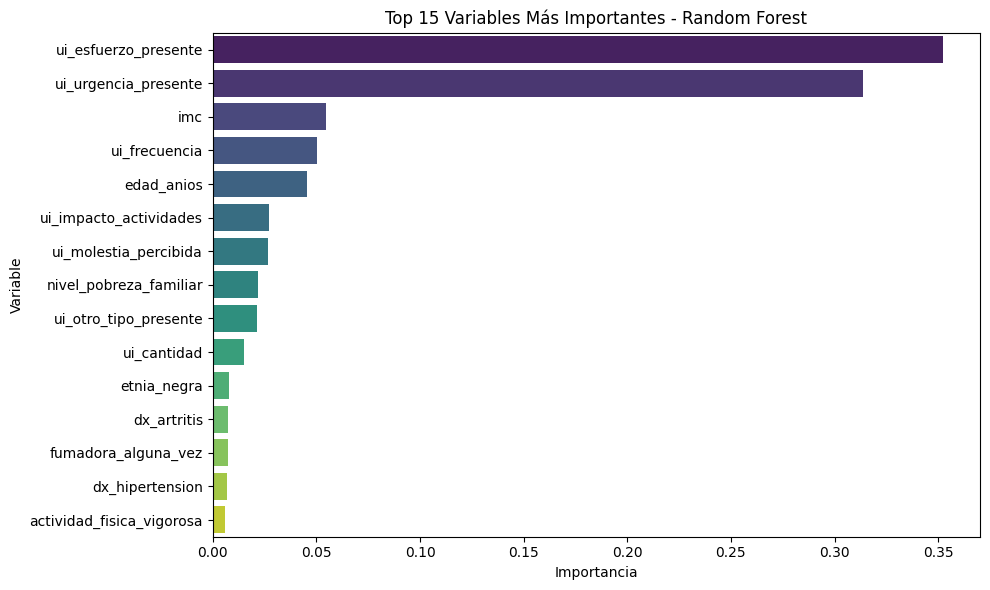

In [ ]:
# Obtenemos la importancia de cada columna
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

# Creamos un DataFrame para graficar fácilmente
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 6. Métricas Finales

In [ ]:
acc = accuracy_score(y_test, y_pred_tuned)
f1m = f1_score(y_test, y_pred_tuned, average='macro')

print("=== MÉTRICAS GLOBALES ===")
print(f"Accuracy:  {acc:.4f}")
print(f"F1-Macro:  {f1m:.4f}")
print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred_tuned))

=== MÉTRICAS GLOBALES ===
Accuracy:  0.9460
F1-Macro:  0.9418

=== REPORTE DE CLASIFICACIÓN DETALLADO ===
              precision    recall  f1-score   support

       mixed       0.94      0.99      0.96       328
        none       0.98      0.91      0.95       972
      stress       0.90      0.99      0.94       317
        urge       0.87      0.95      0.91       198

    accuracy                           0.95      1815
   macro avg       0.92      0.96      0.94      1815
weighted avg       0.95      0.95      0.95      1815



## 7. Guardar el Modelo Afinado

In [ ]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "random_forest.pkl")

joblib.dump(rf_tuned, model_path)
print(f"✅ Modelo exportado correctamente en: {model_path}")

✅ Modelo exportado correctamente en: ../models/random_forest.pkl
